In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096024,128.834003,122.210227,128.223793,112117500
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700
2023-01-06,127.574188,128.233612,122.918847,124.021172,87754700
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800


In [3]:
data["Returns"] = data["Close"].pct_change()
data.head()

Price,Close,High,Low,Open,Volume,Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2023-01-03,123.096024,128.834003,122.210227,128.223793,112117500,NaN
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600,0.010314
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700,-0.010605
2023-01-06,127.574188,128.233612,122.918847,124.021172,87754700,0.036794
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800,0.004089


In [4]:
data["SMA20"] = data["Close"].rolling(window=20).mean()
data["SMA50"] = data["Close"].rolling(window=50).mean()

data.head(60)

Price,Close,High,Low,Open,Volume,Returns,SMA20,SMA50
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2023-01-03,123.096024,128.834003,122.210227,128.223793,112117500,NaN,NaN,NaN
2023-01-04,124.365662,126.629364,123.105865,124.887295,89113600,0.010314,NaN,NaN
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700,-0.010605,NaN,NaN
2023-01-06,127.574188,128.233612,122.918847,124.021172,87754700,0.036794,NaN,NaN
2023-01-09,128.095856,131.304413,127.839965,128.410812,70790800,0.004089,NaN,NaN
2023-01-10,128.666656,129.188290,126.097850,128.204073,63896200,0.004456,NaN,NaN
2023-01-11,131.383133,131.402806,128.400957,129.178481,69458900,0.021113,NaN,NaN
2023-01-12,131.304398,132.140973,129.365489,131.766981,71379600,-0.000599,NaN,NaN


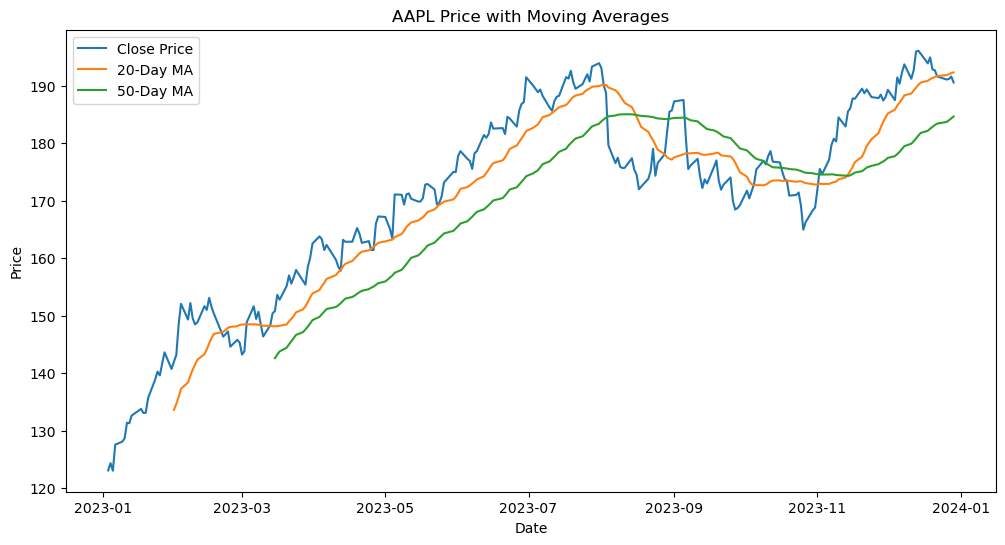

In [5]:
plt.figure(figsize=(12,6))

plt.plot(data["Close"], label="Close Price")
plt.plot(data["SMA20"], label="20-Day MA")
plt.plot(data["SMA50"], label="50-Day MA")

plt.title("AAPL Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [6]:
data["Signal"] = 0

data.loc[data["SMA20"] > data["SMA50"], "Signal"] = 1

data[["Close", "SMA20", "SMA50", "Signal"]].tail(20)

Price,Close,SMA20,SMA50,Signal
Ticker,AAPL,,,
Date,,,,
2023-12-01,189.273743,185.175402,177.446826,1
2023-12-04,187.482330,185.819334,177.741168,1
2023-12-05,191.431305,186.533208,178.088988,1
2023-12-06,190.342651,187.064649,178.496480,1
2023-12-07,192.272614,187.639708,178.972817,1
2023-12-08,193.697784,188.309747,179.472518,1
2023-12-11,191.193787,188.645262,179.911859,1
2023-12-12,192.708069,189.135669,180.331274,1


In [7]:
data.loc[data["SMA20"] > data["SMA50"], "Signal"] = 1

In [8]:
data[["Close", "SMA20", "SMA50", "Signal"]].tail(20)

Price,Close,SMA20,SMA50,Signal
Ticker,AAPL,,,
Date,,,,
2023-12-01,189.273743,185.175402,177.446826,1
2023-12-04,187.482330,185.819334,177.741168,1
2023-12-05,191.431305,186.533208,178.088988,1
2023-12-06,190.342651,187.064649,178.496480,1
2023-12-07,192.272614,187.639708,178.972817,1
2023-12-08,193.697784,188.309747,179.472518,1
2023-12-11,191.193787,188.645262,179.911859,1
2023-12-12,192.708069,189.135669,180.331274,1


In [9]:
data["Signal"].value_counts()

Signal
1    138
0    112
Name: count, dtype: int64

In [10]:
data[["Close", "SMA20", "SMA50", "Signal"]].head(100)

Price,Close,SMA20,SMA50,Signal
Ticker,AAPL,,,
Date,,,,
2023-01-03,123.096024,NaN,NaN,0
2023-01-04,124.365662,NaN,NaN,0
2023-01-05,123.046806,NaN,NaN,0
2023-01-06,127.574188,NaN,NaN,0
2023-01-09,128.095856,NaN,NaN,0
...,...,...,...,...
2023-05-19,172.897491,168.041460,162.199951,1
2023-05-22,171.949875,168.490502,162.711361,1


In [11]:
data["Strategy Returns"] = data["Returns"] * data["Signal"]
data[["Returns", "Signal", "Strategy Returns"]].head(20)

Price,Returns,Signal,Strategy Returns
Ticker,,,
Date,,,
2023-01-03,NaN,0,NaN
2023-01-04,0.010314,0,0.0
2023-01-05,-0.010605,0,-0.0
2023-01-06,0.036794,0,0.0
2023-01-09,0.004089,0,0.0
2023-01-10,0.004456,0,0.0
2023-01-11,0.021113,0,0.0
2023-01-12,-0.000599,0,-0.0


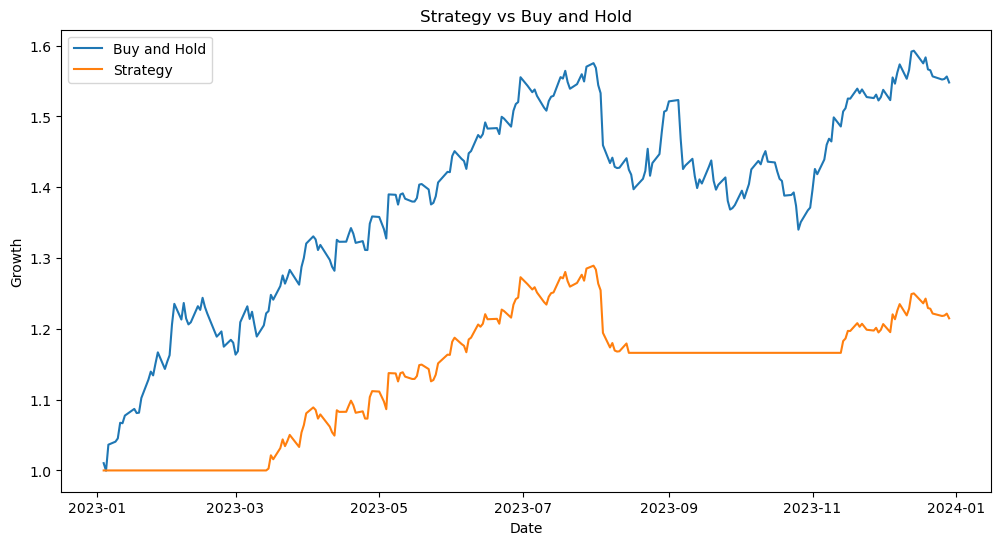

In [12]:
data["Buy and Hold Growth"] = (1 + data["Returns"]).cumprod()
data["Strategy Growth"] = (1 + data["Strategy Returns"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(data["Buy and Hold Growth"], label="Buy and Hold")
plt.plot(data["Strategy Growth"], label="Strategy")
plt.title("Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.show()

Sharpe Ratio

In [13]:
data["Strategy Returns"].mean() / data["Strategy Returns"].std()

np.float64(0.09915703149032505)

2. Drawdown
What drawdown means

Drawdown shows:

how far your strategy falls from its highest point

So if your strategy grows to 1.30, then drops to 1.20:

peak = 1.30
current = 1.20
drawdown = about -7.7%

That helps measure risk.

In [14]:
data["Strategy Peak"] = data["Strategy Growth"].cummax()
data["Strategy Drawdown"] = (data["Strategy Growth"] - data["Strategy Peak"]) / data["Strategy Peak"]

data[["Strategy Growth", "Strategy Peak", "Strategy Drawdown"]].head(20)

Price,Strategy Growth,Strategy Peak,Strategy Drawdown
Ticker,,,
Date,,,
2023-01-03,NaN,NaN,NaN
2023-01-04,1.0,1.0,0.0
2023-01-05,1.0,1.0,0.0
2023-01-06,1.0,1.0,0.0
2023-01-09,1.0,1.0,0.0
2023-01-10,1.0,1.0,0.0
2023-01-11,1.0,1.0,0.0
2023-01-12,1.0,1.0,0.0


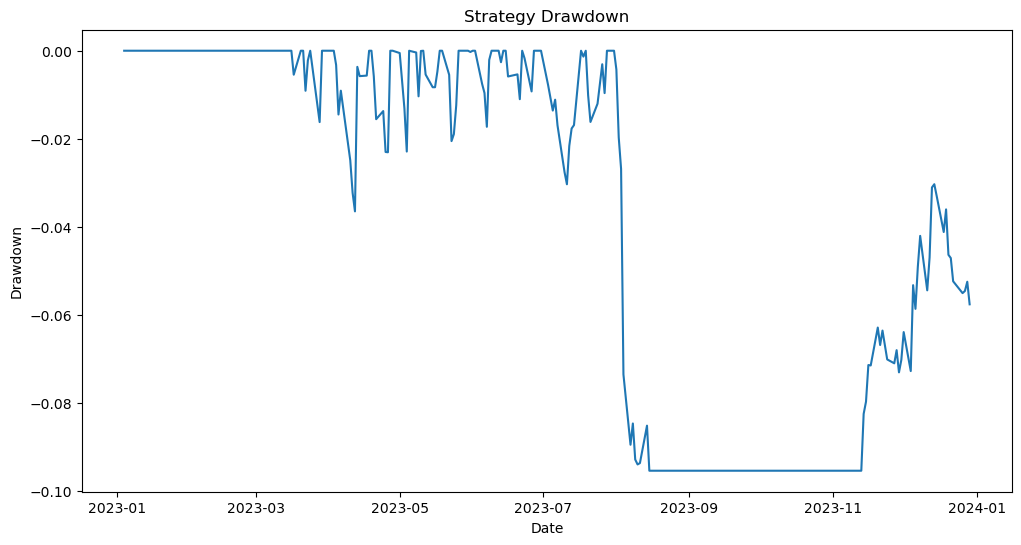

In [15]:
plt.figure(figsize=(12,6))
plt.plot(data["Strategy Drawdown"])
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

In [16]:
print("Maximum Drawdown:", data["Strategy Drawdown"].min())

Maximum Drawdown: -0.09549688481818171


The strategy had a maximum drawdown of ~9.5%, indicating moderate downside risk.

In [29]:
data["BH Peak"] = data["Buy and Hold Growth"].cummax()
data["BH Drawdown"] = (data["Buy and Hold Growth"] - data["BH Peak"]) / data["BH Peak"]

print("Buy & Hold Max Drawdown:", data["BH Drawdown"].min())

Buy & Hold Max Drawdown: -0.14932350622395069


RSI is:

RSI = Relative Strength Index

It measures recent price strength.

Common interpretation:

RSI < 30 → oversold
RSI > 70 → overbought

For this beginner project, we’ll test a simple rule:

1. buy when RSI < 30
2. otherwise stay out

In [17]:
delta = data["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

delta = day-to-day price change

gain = only positive changes

loss = only negative changes, turned positive

In [18]:
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

In [19]:
rs = avg_gain / avg_loss
data["RSI"] = 100 - (100 / (1 + rs))

data[["Close", "RSI"]].head(20)

Price,Close,RSI
Ticker,AAPL,
Date,,
2023-01-03,123.096024,NaN
2023-01-04,124.365662,NaN
2023-01-05,123.046806,NaN
2023-01-06,127.574188,NaN
2023-01-09,128.095856,NaN
2023-01-10,128.666656,NaN
2023-01-11,131.383133,NaN
2023-01-12,131.304398,NaN


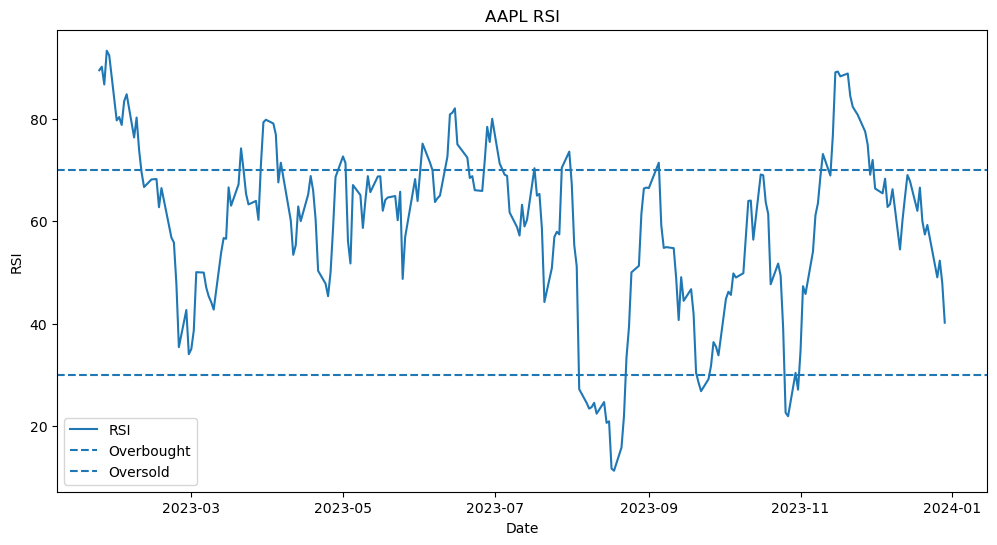

In [20]:
plt.figure(figsize=(12,6))
plt.plot(data["RSI"], label="RSI")
plt.axhline(70, linestyle="--", label="Overbought")
plt.axhline(30, linestyle="--", label="Oversold")
plt.title("AAPL RSI")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.show()

In [21]:
data["RSI Signal"] = 0
data.loc[data["RSI"] < 30, "RSI Signal"] = 1

data[["RSI", "RSI Signal"]].tail(20)

Price,RSI,RSI Signal
Ticker,,
Date,,
2023-12-01,66.351377,0
2023-12-04,65.422951,0
2023-12-05,68.276145,0
2023-12-06,62.759076,0
2023-12-07,63.302244,0
2023-12-08,66.217688,0
2023-12-11,54.474883,0
2023-12-12,60.149652,0


1. RSI Signal = 1 → buy

2. RSI Signal = 0 → stay out

In [45]:
data["RSI Strategy Returns"] = data["Returns"] * data["RSI Signal"]
data["RSI Strategy Growth"] = (1 + data["RSI Strategy Returns"]).cumprod()

data[["Returns", "RSI Signal", "RSI Strategy Returns"]].head(20)

Price,Returns,RSI Signal,RSI Strategy Returns
Ticker,,,
Date,,,
2023-01-03,NaN,0,NaN
2023-01-04,0.010314,0,0.0
2023-01-05,-0.010605,0,-0.0
2023-01-06,0.036794,0,0.0
2023-01-09,0.004089,0,0.0
2023-01-10,0.004456,0,0.0
2023-01-11,0.021113,0,0.0
2023-01-12,-0.000599,0,-0.0


In [22]:
data["RSI Strategy Returns"] = data["Returns"] * data["RSI Signal"]
data["RSI Strategy Growth"] = (1 + data["RSI Strategy Returns"]).cumprod()

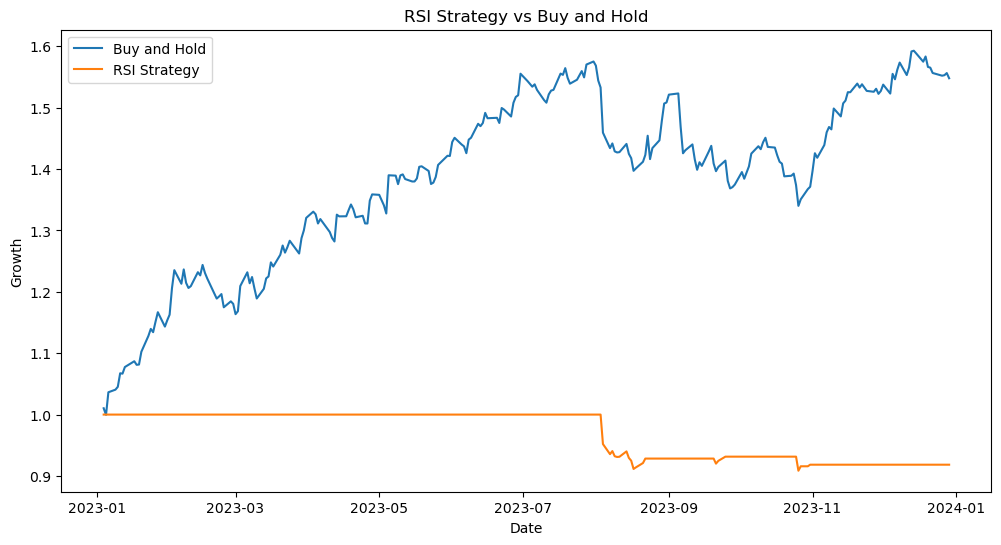

In [23]:
plt.figure(figsize=(12,6))
plt.plot(data["Buy and Hold Growth"], label="Buy and Hold")
plt.plot(data["RSI Strategy Growth"], label="RSI Strategy")
plt.title("RSI Strategy vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.show()

In [35]:
print("Final Buy and Hold Value:", data["Buy and Hold Growth"].iloc[-1])
print("Final RSI Strategy Value:", data["RSI Strategy Growth"].iloc[-1])
print("RSI Strategy Sharpe Ratio:", data["RSI Strategy Returns"].mean() / data["RSI Strategy Returns"].std())

Final Buy and Hold Value: 1.547982384516305
Final RSI Strategy Value: 0.918356303981338
RSI Strategy Sharpe Ratio: -0.0820278590529204


In [24]:
data["Combined Signal"] = 0
data.loc[(data["SMA20"] > data["SMA50"]) & (data["RSI"] < 70), "Combined Signal"] = 1

data["Combined Strategy Returns"] = data["Returns"] * data["Combined Signal"]
data["Combined Strategy Growth"] = (1 + data["Combined Strategy Returns"]).cumprod()

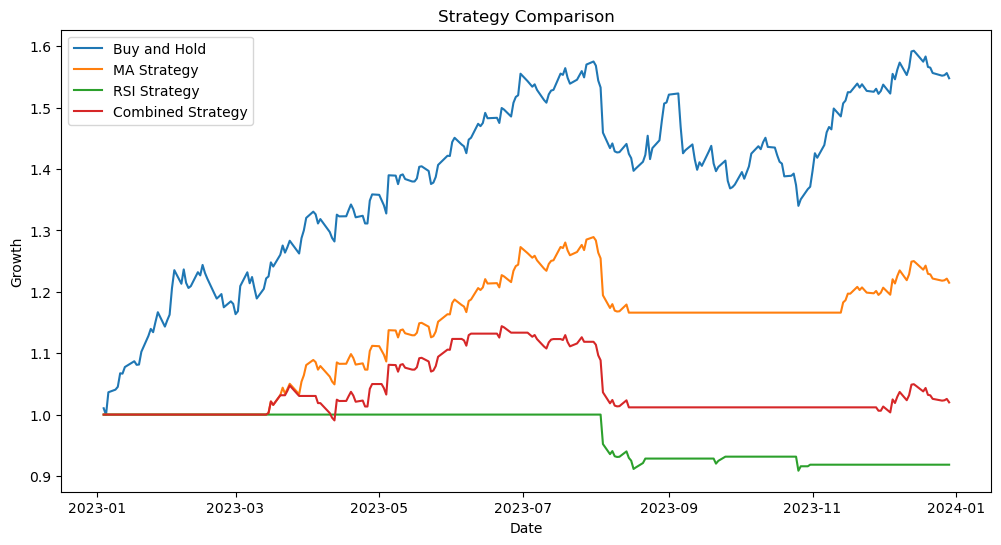

In [25]:
plt.figure(figsize=(12,6))
plt.plot(data["Buy and Hold Growth"], label="Buy and Hold")
plt.plot(data["Strategy Growth"], label="MA Strategy")
plt.plot(data["RSI Strategy Growth"], label="RSI Strategy")
plt.plot(data["Combined Strategy Growth"], label="Combined Strategy")
plt.title("Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.show()

In [30]:
delta = data["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

delta = day-to-day price change

gain = only positive changes

loss = only negative changes, turned positive

In [39]:
print("Buy and Hold Final Value:", data["Buy and Hold Growth"].iloc[-1])
print("MA Strategy Final Value:", data["Strategy Growth"].iloc[-1])
print("RSI Strategy Final Value:", data["RSI Strategy Growth"].iloc[-1])
print("Combined Strategy Final Value:", data["Combined Strategy Growth"].iloc[-1])

print("Combined Strategy Sharpe Ratio:", data["Combined Strategy Returns"].mean() / data["Combined Strategy Returns"].std())

Buy and Hold Final Value: 1.547982384516305
MA Strategy Final Value: 1.2148781862009776
RSI Strategy Final Value: 1.0
Combined Strategy Final Value: 1.0199746270064527
Combined Strategy Sharpe Ratio: 0.014429450992370741


In [40]:
transaction_cost = 0.001  # 0.1% per trade

data["Trade"] = data["Combined Signal"].diff().abs()
data["Cost"] = data["Trade"] * transaction_cost

data["Combined Strategy Returns"] = (data["Returns"] * data["Combined Signal"]) - data["Cost"]
data["Combined Strategy Growth"] = (1 + data["Combined Strategy Returns"]).cumprod()

In [41]:
stop_loss = -0.05  # -5%

data["Position"] = data["Combined Signal"]

for i in range(1, len(data)):
    if data["Position"].iloc[i-1] == 1:
        if data["Returns"].iloc[i] < stop_loss:
            data.loc[data.index[i], "Position"] = 0
        else:
            data.loc[data.index[i], "Position"] = data["Combined Signal"].iloc[i]
    else:
        data.loc[data.index[i], "Position"] = data["Combined Signal"].iloc[i]

In [42]:
data["Combined Strategy Returns"] = data["Returns"] * data["Position"]
data["Combined Strategy Growth"] = (1 + data["Combined Strategy Returns"]).cumprod()

In [43]:
results = []

for rsi_threshold in [20, 30, 40]:
    temp = data.copy()

    temp["Signal"] = 0
    temp.loc[(temp["SMA20"] > temp["SMA50"]) & (temp["RSI"] < rsi_threshold), "Signal"] = 1

    temp["Returns_Strategy"] = temp["Returns"] * temp["Signal"]
    final_value = (1 + temp["Returns_Strategy"]).cumprod().iloc[-1]

    results.append((rsi_threshold, final_value))

print(results)

[(20, np.float64(1.0)), (30, np.float64(1.0)), (40, np.float64(1.0))]


In [44]:
import yfinance as yf

tickers = ["AAPL", "TSLA", "NVDA"]

all_results = {}

for ticker in tickers:
    temp = yf.download(ticker, start="2023-01-01", end="2024-01-01")

    temp["Returns"] = temp["Close"].pct_change()

    temp["SMA20"] = temp["Close"].rolling(20).mean()
    temp["SMA50"] = temp["Close"].rolling(50).mean()

    delta = temp["Close"].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    temp["RSI"] = 100 - (100 / (1 + rs))

    temp["Signal"] = 0
    temp.loc[(temp["SMA20"] > temp["SMA50"]) & (temp["RSI"] < 70), "Signal"] = 1

    temp["Strategy Returns"] = temp["Returns"] * temp["Signal"]
    temp["Growth"] = (1 + temp["Strategy Returns"]).cumprod()

    all_results[ticker] = temp["Growth"].iloc[-1]

print(all_results)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

{'AAPL': np.float64(1.0199746270064527), 'TSLA': np.float64(0.7942594997818179), 'NVDA': np.float64(1.126555726172397)}


## Multi-Asset Test Results

The combined strategy was also tested on multiple stocks:

- **AAPL:** ~1.02 final growth
- **TSLA:** ~0.79 final growth
- **NVDA:** ~1.27 final growth

### Interpretation
The strategy performed inconsistently across assets. It worked best on NVDA, was only slightly profitable on AAPL, and underperformed on TSLA. This suggests that the strategy is not robust across all market conditions and is sensitive to the behavior of individual stocks.

## Conclusion

This project compared multiple rule-based trading strategies against a buy-and-hold benchmark.

The results showed that buy-and-hold outperformed the tested strategies on AAPL in 2023. The moving average strategy performed better than RSI and the combined strategy, but still lagged behind buy-and-hold. Multi-asset testing showed that the combined strategy worked better on NVDA than on AAPL or TSLA, indicating that strategy performance is highly dependent on stock behavior and market conditions.